In [3]:
import torch
import torch.nn as nn

import numpy as np

import matplotlib.pyplot as plt

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=32, batch_size=128)

In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

c:\Users\rafae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([128, 3, 32, 32])
torch.Size([128])


In [6]:
model = nn.Sequential(

    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(64 * 8 * 8, 128),
    nn.ReLU(),

    nn.Linear(128, NUM_CLASSES)
)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=4096, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=43, bias=True)
)

In [8]:
criterion = nn.CrossEntropyLoss()

In [9]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [10]:
epochs = 5

losses = []
accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")


    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    losses.append(running_loss)
    
    accuracy = 100 * correct / total

    accuracies.append(accuracy)

    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1, Loss: 291.9056
Validation Accuracy: 85.77%
Epoch 2, Loss: 55.4971
Validation Accuracy: 94.89%
Epoch 3, Loss: 24.8228
Validation Accuracy: 95.31%
Epoch 4, Loss: 16.4860
Validation Accuracy: 97.79%
Epoch 5, Loss: 8.1578
Validation Accuracy: 98.57%


In [11]:
model.eval()

all_preds = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_preds.append(predictions.cpu())

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

    print(f"Test Global Accuracy: {accuracy:.2f}%")
    #print(acc)


y_pred = torch.cat(all_preds)



Test Global Accuracy: 87.45%


In [14]:
model.eval()

cm = np.zeros((43,43), dtype=int)

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        for label, prediction in zip(labels, predictions):
            cm[label, prediction] += 1

np.set_printoptions(threshold=np.inf)

print(cm)

c:\Users\rafae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[[ 41  12   0   0   1   1   0   0   5   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  8 631  52   1  21   0   0   1   3   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   1   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  3  18 717   2   8   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   1   1   0   0   0
    0   0   0   0   0   0   0]
 [  0   0   1 423   0  17   2   0   0   0   3   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   2   1   0   0   1   0
    0   0   0   0   0   0   0]
 [  1   8  10   3 616   3   0  12   2   0   1   0   0   1   1   0   0   0
    0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   1  36  30   3 522   0  17   5   1   3   0   0   0   1   2   0   0
    0   0   0   0   0   0   0  

In [15]:
acc_class = [0 for c in GTSRB_CLASSES]
for i in range(43):
  acc = 100 * (float(cm[i,i]) / np.sum(cm[i, :]))
  print(f'Acurácia {i}: {acc:.2f}')
  acc_class[i] = acc

print(f"Worst class: {acc_class.index(min(acc_class))} - {min(acc_class):.2f}%")
print(f"Best class: {acc_class.index(max(acc_class))} - {max(acc_class):.2f}%")
print(f"")

Acurácia 0: 68.33
Acurácia 1: 87.64
Acurácia 2: 95.60
Acurácia 3: 94.00
Acurácia 4: 93.33
Acurácia 5: 82.86
Acurácia 6: 71.33
Acurácia 7: 82.22
Acurácia 8: 86.00
Acurácia 9: 88.96
Acurácia 10: 98.18
Acurácia 11: 87.62
Acurácia 12: 95.36
Acurácia 13: 99.03
Acurácia 14: 97.04
Acurácia 15: 95.24
Acurácia 16: 76.67
Acurácia 17: 87.22
Acurácia 18: 71.03
Acurácia 19: 58.33
Acurácia 20: 80.00
Acurácia 21: 50.00
Acurácia 22: 92.50
Acurácia 23: 60.67
Acurácia 24: 84.44
Acurácia 25: 88.75
Acurácia 26: 78.89
Acurácia 27: 46.67
Acurácia 28: 76.67
Acurácia 29: 85.56
Acurácia 30: 48.00
Acurácia 31: 84.44
Acurácia 32: 95.00
Acurácia 33: 95.71
Acurácia 34: 95.00
Acurácia 35: 97.69
Acurácia 36: 95.00
Acurácia 37: 100.00
Acurácia 38: 87.83
Acurácia 39: 61.11
Acurácia 40: 54.44
Acurácia 41: 56.67
Acurácia 42: 66.67
Worst class: 27 - 46.67%
Best class: 37 - 100.00%



In [15]:
save_predictions(
    y_pred,
    "results/predicoes_baseline.csv",
    experiment_name="CNN Baseline"
)

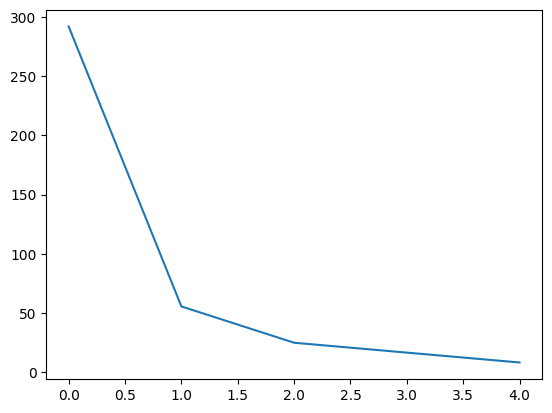

In [12]:
plt.plot(losses)
plt.show()

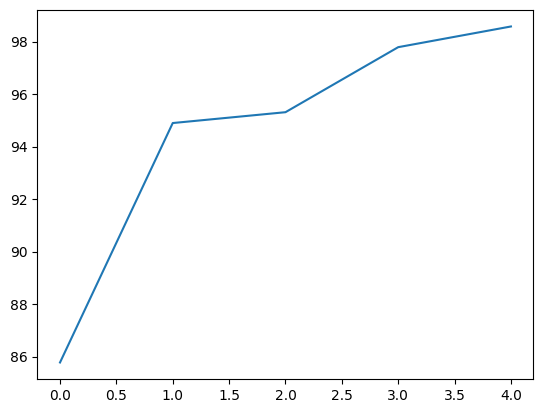

In [13]:
plt.plot(accuracies)
plt.show()

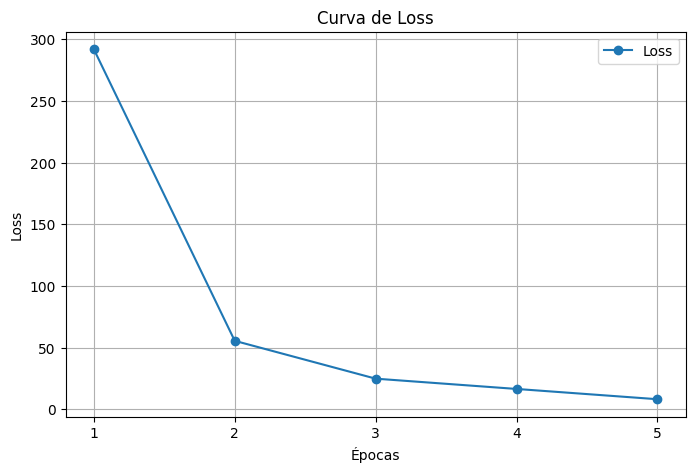

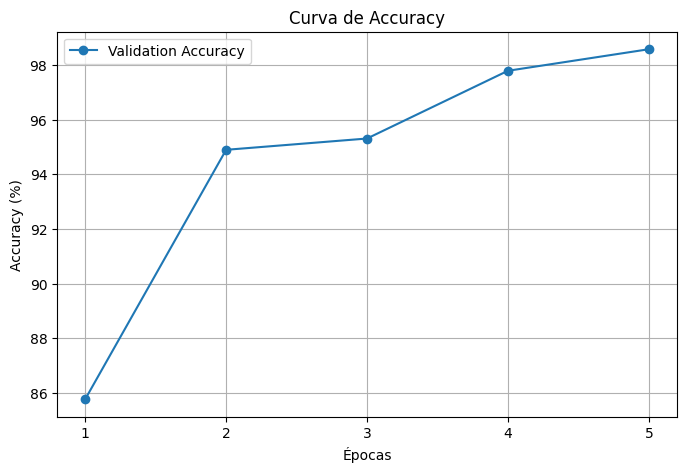

In [16]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    losses,
    marker='o',
    label='Loss'
)

plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    accuracies,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()